In [ ]:
Client - I want u to create a tool which will predict refinance volumes --- for this I have provided daatset and u need to come up with ur solution and ur predictions

Regression -- 

In [ ]:
Linear reg  --- model1
Measure the accuracy

Lasso reg -- model2
Measure the accuracy

Ridge reg -- model3

Decision tree regressor
without hyper parametr tuning - model
Random fore

Xgboost regressor

With Hyper paramter tuning again i will train the model and check the acuracy

In [3]:
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)
import pandas as pd
import os
#import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
#import matplotlib.pyplot as plt

In [5]:
import pandas as pd
d1=pd.read_excel('Weekly_Refinance_Volumes_Data.xlsx')

In [6]:
d1.head()

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,2018-12-31,1,1,2019,885.0,4.51,1.6,187.901424,1.700000,4.0,2.4,101.008462,101.0012,329495.250000,16027.8
1,2019-01-07,2,1,2019,1094.0,4.51,1.6,187.901424,2.160000,4.0,2.4,101.008462,101.0012,348680.142857,16027.8
2,2019-01-14,3,1,2019,1078.0,4.51,1.6,187.901424,2.195714,4.0,2.4,101.008462,101.0012,322446.857143,16027.8
3,2019-01-21,4,1,2019,1032.0,4.51,1.6,187.901424,1.747143,4.0,2.4,101.008462,101.0012,264000.714286,16027.8
4,2019-01-28,5,2,2019,989.0,4.51,1.5,188.841570,2.168571,3.8,2.4,101.065220,101.0591,251632.285714,16073.8


In [7]:
d1.columns

Index(['Date', 'Week No', 'Month No', 'Year', 'Refinance', 'Mortgage Rate',
       'Inflation', 'Housing Price Index', 'Treasury Yield',
       'Unemployment Rate', 'GDP', 'Business Confidence Index',
       'Consumer Confidence Index', 'Initial Unemployment Claim',
       'Disposable Income'],
      dtype='object')

Y= mX+c   --- x- independent features
Y - Dependent feature

Independent features --- except Refinance, remaining all features are independent features(Input columns)
Dependent Features --- Refinance(Target column or output column)

In [8]:
d1.tail()

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
196,2022-10-02,40,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
197,2022-10-09,41,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
198,2022-10-16,42,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
199,2022-10-23,43,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
200,2022-10-30,44,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143


All the ML models --- We will be using Sklearn Library    -- scikit learn  

All the Deep Learning Models -- we will using tensorfow,keras    or Pytorch     

In [9]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        201 non-null    datetime64[ns]
 1   Week No                     201 non-null    int64         
 2   Month No                    201 non-null    int64         
 3   Year                        201 non-null    int64         
 4   Refinance                   188 non-null    float64       
 5   Mortgage Rate               201 non-null    float64       
 6   Inflation                   201 non-null    float64       
 7   Housing Price Index         201 non-null    float64       
 8   Treasury Yield              201 non-null    float64       
 9   Unemployment Rate           201 non-null    float64       
 10  GDP                         201 non-null    float64       
 11  Business Confidence Index   201 non-null    float64       

In [10]:
d1.shape

(201, 15)

In [11]:
d1.dtypes

Date                          datetime64[ns]
Week No                                int64
Month No                               int64
Year                                   int64
Refinance                            float64
Mortgage Rate                        float64
Inflation                            float64
Housing Price Index                  float64
Treasury Yield                       float64
Unemployment Rate                    float64
GDP                                  float64
Business Confidence Index            float64
Consumer Confidence Index            float64
Initial Unemployment Claim           float64
Disposable Income                    float64
dtype: object

In [9]:
#d1['Time']=pd.to_datetime(d1['Time'])

In [12]:
d1.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,201,2020-11-29 23:24:10.746268672,2018-12-31 00:00:00,2019-12-16 00:00:00,2020-11-30 00:00:00,2021-11-15 00:00:00,2022-10-30 00:00:00,NaN
Week No,201.0,25.756219,1.0,13.0,26.0,38.0,53.0,14.752806
Month No,201.0,6.353234,1.0,3.0,6.0,9.0,12.0,3.371884
Year,201.0,2020.442786,2019.0,2019.0,2020.0,2021.0,2022.0,1.099072
Refinance,188.0,2424.271277,464.0,1729.5,2514.0,2953.5,4636.0,963.107935
Mortgage Rate,201.0,3.661015,2.65,2.98,3.49,4.08,5.81,0.852269
Inflation,201.0,3.925373,0.1,1.5,2.3,6.8,9.1,3.028267
Housing Price Index,201.0,226.880017,187.901424,195.660059,217.835281,254.163779,282.693917,31.316747
Treasury Yield,201.0,1.608493,0.758571,1.174286,1.587143,1.938,3.012,0.514188
Unemployment Rate,201.0,5.270647,3.5,3.6,3.9,6.0,14.7,2.608732


In [13]:
d1.corr()

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
Date,1.000000,0.166146,0.169783,0.967623,-0.123965,0.228560,0.865019,0.971833,0.315295,-0.101655,0.079948,-0.917096,0.353412,-0.133536,0.743464
Week No,0.166146,1.000000,0.996016,-0.079961,0.109263,-0.091306,0.068320,0.104377,-0.203068,-0.012295,0.243292,-0.140269,-0.294710,-0.108628,-0.048424
Month No,0.169783,0.996016,1.000000,-0.076145,0.108547,-0.096064,0.077024,0.112433,-0.199703,-0.021552,0.248530,-0.140870,-0.296843,-0.116258,-0.042619
Year,0.967623,-0.079961,-0.076145,1.000000,-0.151427,0.249639,0.851703,0.953012,0.370420,-0.095542,0.018550,-0.891213,0.430231,-0.104241,0.761469
Refinance,-0.123965,0.109263,0.108547,-0.151427,1.000000,-0.793394,-0.539903,-0.316003,-0.799932,0.640308,-0.077872,0.108996,-0.544023,0.517231,0.163869
Mortgage Rate,0.228560,-0.091306,-0.096064,0.249639,-0.793394,1.000000,0.535009,0.342911,0.802627,-0.447990,-0.109823,-0.285155,0.604182,-0.262231,-0.063043
Inflation,0.865019,0.068320,0.077024,0.851703,-0.539903,0.535009,1.000000,0.940686,0.632321,-0.473086,0.064623,-0.759693,0.574503,-0.401744,0.476062
Housing Price Index,0.971833,0.104377,0.112433,0.953012,-0.316003,0.342911,0.940686,1.000000,0.470021,-0.239176,0.080091,-0.894889,0.456975,-0.240102,0.671053
Treasury Yield,0.315295,-0.203068,-0.199703,0.370420,-0.799932,0.802627,0.632321,0.470021,1.000000,-0.613565,-0.002383,-0.275263,0.725396,-0.476756,0.043985
Unemployment Rate,-0.101655,-0.012295,-0.021552,-0.095542,0.640308,-0.447990,-0.473086,-0.239176,-0.613565,1.000000,-0.263887,-0.098233,-0.452111,0.841997,0.294871


In [12]:
d1.isnull().sum()

Date                           0
Week No                        0
Month No                       0
Year                           0
Refinance                     13
Mortgage Rate                  0
Inflation                      0
Housing Price Index            0
Treasury Yield                 0
Unemployment Rate              0
GDP                            0
Business Confidence Index      0
Consumer Confidence Index      0
Initial Unemployment Claim     0
Disposable Income              0
dtype: int64

In [14]:
future_data  = d1[d1['Refinance'].isna()]

In [15]:
future_data.head(2)

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
188,2022-08-08,32,8,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
189,2022-08-15,33,8,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143


In [16]:
future_data.shape

(13, 15)

In [17]:
base_data = d1[~d1['Refinance'].isna()]

In [19]:
base_data.head(2)

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,2018-12-31,1,1,2019,885.0,4.51,1.6,187.901424,1.70,4.0,2.4,101.008462,101.0012,329495.250000,16027.8
1,2019-01-07,2,1,2019,1094.0,4.51,1.6,187.901424,2.16,4.0,2.4,101.008462,101.0012,348680.142857,16027.8


In [20]:
base_data.tail(2)

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
186,2022-07-25,30,7,2022,805.0,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
187,2022-08-01,31,8,2022,891.0,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143


In [21]:
base_data.isna().sum()

Date                          0
Week No                       0
Month No                      0
Year                          0
Refinance                     0
Mortgage Rate                 0
Inflation                     0
Housing Price Index           0
Treasury Yield                0
Unemployment Rate             0
GDP                           0
Business Confidence Index     0
Consumer Confidence Index     0
Initial Unemployment Claim    0
Disposable Income             0
dtype: int64

In [22]:
base_data=base_data.drop('Date',axis=1)

In [24]:
x=base_data.drop('Refinance',axis=1)
y=base_data['Refinance']

In [25]:
x.head(2)

,Week No,Month No,Year,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,1,1,2019,4.51,1.6,187.901424,1.70,4.0,2.4,101.008462,101.0012,329495.250000,16027.8
1,2,1,2019,4.51,1.6,187.901424,2.16,4.0,2.4,101.008462,101.0012,348680.142857,16027.8


In [26]:
y.head(2)

0     885.0
1    1094.0
Name: Refinance, dtype: float64

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.05,random_state=10)

In [28]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(178, 13) (10, 13) (178,) (10,)


In [30]:
X_train

,Week No,Month No,Year,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
151,47,11,2021,2.98,6.8,254.163779,1.112857,4.2,6.9,97.840650,97.55445,2.429736e+05,18269.5
35,36,9,2019,3.58,1.7,195.251489,1.142857,3.5,2.8,100.901832,100.89250,1.740377e+05,16319.7
117,13,4,2021,3.09,4.2,233.429418,1.701429,6.0,6.7,99.889056,99.81000,7.279619e+05,18429.9
152,48,12,2021,3.10,7.0,256.671745,1.267143,3.9,6.9,97.734888,97.78466,2.361136e+05,18329.5
76,25,6,2020,3.21,0.6,204.569875,1.064286,11.0,-31.2,98.426597,98.36909,1.454252e+06,17805.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,9,3,2021,2.81,2.6,228.078785,1.610000,6.0,6.3,99.633189,99.54000,7.467864e+05,21698.9
64,13,3,2020,3.65,1.5,200.276893,0.982857,4.4,-5.1,100.139162,100.11500,3.790587e+06,16444.3
15,16,4,2019,4.12,2.0,191.975593,1.700000,3.6,3.2,101.461097,101.46270,2.007634e+05,16110.1
125,21,5,2021,2.94,5.0,239.040006,1.627143,5.8,6.7,99.827589,99.76000,4.220746e+05,17980.6


In [31]:
y

0       885.0
1      1094.0
2      1078.0
3      1032.0
4       989.0
        ...  
183     464.0
184     628.0
185     794.0
186     805.0
187     891.0
Name: Refinance, Length: 188, dtype: float64

In [33]:
y_test

143    2789.0
10     1248.0
5      1188.0
59     2993.0
103    1881.0
19     1978.0
83     3886.0
47     1624.0
2      1078.0
102    3123.0
Name: Refinance, dtype: float64

In [34]:
from sklearn.linear_model import LinearRegression
ln=LinearRegression()
ln.fit(X_train,y_train)   #-- Training the model with training data
ln.predict(X_test)

array([2683.33373352, 1486.66340322, 1540.68049067, 2796.26084576,
       3406.05883369, 1691.76026905, 3295.0811915 , 2265.01906107,
       1440.75221621, 3334.45110727])

In [35]:
abs(y_test.values-ln.predict(X_test)).sum()   -- absolute error
Mean absolute error

np.float64(4511.189072308596)

In [36]:
from sklearn.linear_model import Lasso    #---  L1 Regularisation --
ls=Lasso()
ls.fit(X_train,y_train)
ls.predict(X_test)
abs(y_test.values-ls.predict(X_test)).sum()

C:\Users\Admin\.conda\envs\python_311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.289e+07, tolerance: 1.645e+04
  model = cd_fast.enet_coordinate_descent(


np.float64(4553.747870323015)

In [37]:
from sklearn.linear_model import Ridge # -- L2 Regularisation
rd=Ridge()
rd.fit(X_train,y_train)
rd.predict(X_test)

abs(y_test.values-rd.predict(X_test)).sum()

np.float64(4594.06085241551)

In [38]:
def table_validation():
    validation_table=[]
    for i in [LinearRegression,Lasso,Ridge]:
        rd=i()
        rd.fit(X_train,y_train)
        rd.predict(X_test)
        mae=mean_absolute_error(y_test.values,rd.predict(X_test))
        mse=mean_squared_error(y_test.values,rd.predict(X_test))
        rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
        mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
        rsquare=r2_score(y_test.values,rd.predict(X_test))
        validation_table.append([i,mae,mse,rmse,mape,rsquare])
        #print(type(validation_table))
    validation_table=pd.DataFrame(validation_table)
    validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
    return validation_table

In [39]:
tv=table_validation()

C:\Users\Admin\.conda\envs\python_311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.289e+07, tolerance: 1.645e+04
  model = cd_fast.enet_coordinate_descent(


In [40]:
tv

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,451.118907,357534.424904,597.941824,24.981998,0.571196
1,<class 'sklearn.linear_model._coordinate_desce...,455.374787,361200.960205,600.999967,25.241491,0.566799
2,<class 'sklearn.linear_model._ridge.Ridge'>,459.406085,362737.421136,602.276864,25.561294,0.564956


In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor

In [45]:
def model_validation(method,X_train,X_test,y_train,y_test):
    validation_table=[]
    models=[LinearRegression,Lasso,Ridge,DecisionTreeRegressor,RandomForestRegressor,BaggingRegressor]
    for i in models:
        rd=i()
        rd.fit(X_train,y_train)
        if method=="train":
            rd.predict(X_train)
            mae=mean_absolute_error(y_train.values,rd.predict(X_train))
            mse=mean_squared_error(y_train.values,rd.predict(X_train))
            rmse=np.sqrt(mean_squared_error(y_train.values,rd.predict(X_train)))
            mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])
            rsquare=r2_score(y_train.values,rd.predict(X_train))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
        #validation_table=pd.DataFrame(validation_table_train)
        #validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
        else:  #-- Predict
            rd.predict(X_test)
            mae=mean_absolute_error(y_test.values,rd.predict(X_test))
            mse=mean_squared_error(y_test.values,rd.predict(X_test))
            rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
            mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
            rsquare=r2_score(y_test.values,rd.predict(X_test))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
            
    validation_table=pd.DataFrame(validation_table)
    validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
    return validation_table

In [46]:
pd.options.display.float_format='{:0.2f}'.format

In [47]:
validation_table_train = model_validation('train',X_train,X_test,y_train,y_test)

C:\Users\Admin\.conda\envs\python_311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.289e+07, tolerance: 1.645e+04
  model = cd_fast.enet_coordinate_descent(


In [48]:
validation_table_train

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,307.65,168937.74,411.02,16.78,0.82
1,<class 'sklearn.linear_model._coordinate_desce...,307.76,168995.30,411.09,16.78,0.82
2,<class 'sklearn.linear_model._ridge.Ridge'>,308.85,169171.03,411.30,16.84,0.82
3,<class 'sklearn.tree._classes.DecisionTreeRegr...,0.00,0.00,0.00,0.00,1.00
4,<class 'sklearn.ensemble._forest.RandomForestR...,91.62,19856.33,140.91,4.67,0.98
5,<class 'sklearn.ensemble._bagging.BaggingRegre...,104.57,27645.00,166.27,4.92,0.97


In [49]:
validation_table_test = model_validation('test',X_train,X_test,y_train,y_test)

C:\Users\Admin\.conda\envs\python_311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.289e+07, tolerance: 1.645e+04
  model = cd_fast.enet_coordinate_descent(


In [50]:
validation_table_test

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,451.12,357534.42,597.94,24.98,0.57
1,<class 'sklearn.linear_model._coordinate_desce...,455.37,361200.96,601.00,25.24,0.57
2,<class 'sklearn.linear_model._ridge.Ridge'>,459.41,362737.42,602.28,25.56,0.56
3,<class 'sklearn.tree._classes.DecisionTreeRegr...,523.10,508021.70,712.76,25.01,0.39
4,<class 'sklearn.ensemble._forest.RandomForestR...,389.15,336567.55,580.14,18.55,0.60
5,<class 'sklearn.ensemble._bagging.BaggingRegre...,395.33,321144.94,566.70,19.10,0.61


## The models are working good on the training data but not working well on the testing data, so we need to do further Processing
##### we need to check multicollinearity, if the features are highly correlated, we need to remove one feature from the highly correlated features
##### By Using Lasso regression model , we can check the features coefficients values, if the coeffis having 0 values, we can remove them from the model building


Matplotlib is building the font cache; this may take a moment.


R squared Error on test set :  0.3976905222019078
                   Column_Name  Coefficient_Value_lr
0                      Week No                -39.05
1                     Month No                190.51
2                         Year                553.30
3                Mortgage Rate               -588.89
4                    Inflation                -94.76
5          Housing Price Index                -16.34
6               Treasury Yield               -406.58
7            Unemployment Rate                  4.21
8                          GDP                 -5.16
9    Business Confidence Index                -40.60
10   Consumer Confidence Index                 -1.77
11  Initial Unemployment Claim                  0.00
12           Disposable Income                 -0.03


<BarContainer object of 13 artists>

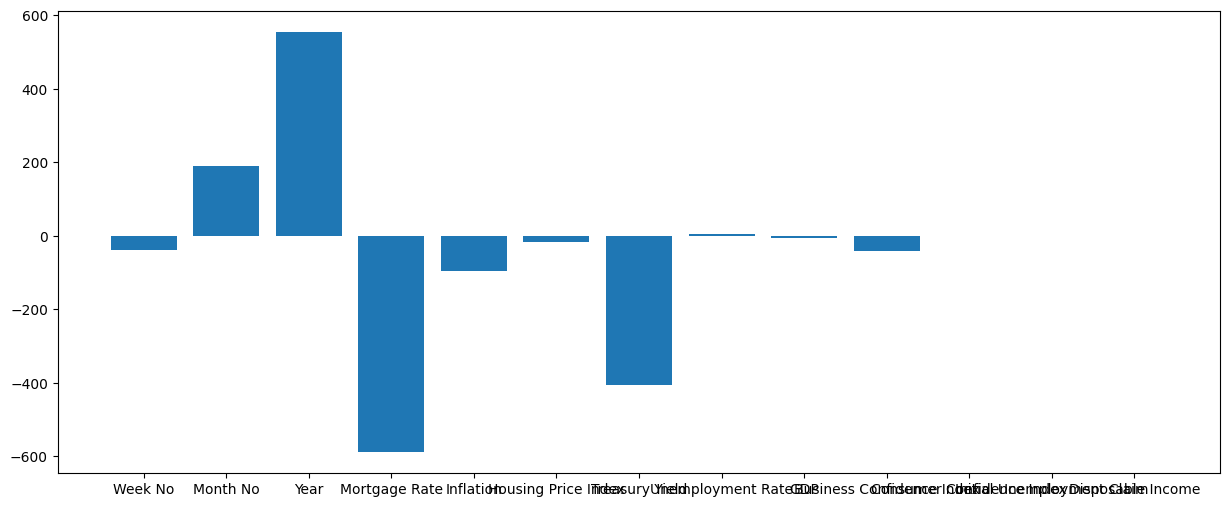

In [52]:
import matplotlib.pyplot as plt
linearreg = LinearRegression()
linearreg.fit(X_train, y_train)

# predicting on test
linearreg_prediction = linearreg.predict(X_test)

# calculating R_square
R_squared = r2_score(linearreg_prediction,y_test)
print("R squared Error on test set : ", R_squared)


# Putting together the coefficient and their corresponding variable names
coefficient_df = pd.DataFrame()
coefficient_df["Column_Name"] = X_train.columns
coefficient_df['Coefficient_Value_lr'] = pd.Series(linearreg.coef_)
print(coefficient_df)
coefficient_df.to_csv('coeff_values.csv',index=False)
plt.rcParams["figure.figsize"] = (15,6)
 
plt.bar(coefficient_df["Column_Name"],coefficient_df["Coefficient_Value_lr"])

In [53]:
coefficient_df = pd.DataFrame()

In [54]:
coefficient_df["Column_Name"] = X_train.columns

In [55]:
coefficient_df

,Column_Name
0,Week No
1,Month No
2,Year
3,Mortgage Rate
4,Inflation
5,Housing Price Index
6,Treasury Yield
7,Unemployment Rate
8,GDP
9,Business Confidence Index


In [56]:
coefficient_df['Coefficient_Value'] = pd.Series(linearreg.coef_)
print(coefficient_df)

                   Column_Name  Coefficient_Value
0                      Week No             -39.05
1                     Month No             190.51
2                         Year             553.30
3                Mortgage Rate            -588.89
4                    Inflation             -94.76
5          Housing Price Index             -16.34
6               Treasury Yield            -406.58
7            Unemployment Rate               4.21
8                          GDP              -5.16
9    Business Confidence Index             -40.60
10   Consumer Confidence Index              -1.77
11  Initial Unemployment Claim               0.00
12           Disposable Income              -0.03


In [46]:
pd.Series(linearreg.coef_)

0     -38.38
1     188.12
2     528.90
3    -588.21
4     -84.25
5     -16.84
6    -403.74
7      18.73
8      -6.17
9     -45.32
10     -1.19
11      0.00
12     -0.02
dtype: float64

In [47]:
linearreg.intercept_

-1054739.1058729673

R squared Error on test set :  0.3823303235507931


<BarContainer object of 13 artists>

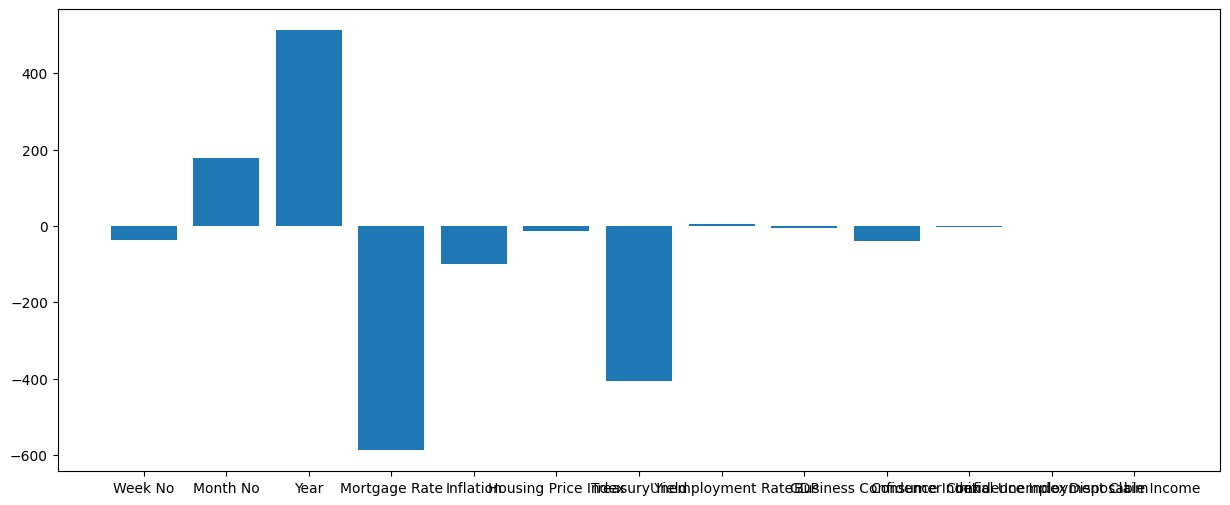

In [57]:
from sklearn.linear_model import Ridge

# Train the model
ridgeRegressor = Ridge(alpha = 0.5) #here setting alpha is nothing but lambda in the formula
ridgeRegressor.fit(X_train, y_train)
y_predicted_ridge = ridgeRegressor.predict(X_test)

# calculating R_square
R_squared = r2_score(y_predicted_ridge,y_test)
print("R squared Error on test set : ", R_squared)

coefficient_df['Coefficient_Value_ridge'] = pd.Series(ridgeRegressor.coef_)
#print(coefficient_df.head)
coefficient_df.to_csv('coeff_values.csv',index=False)
plt.rcParams["figure.figsize"] = (15,6)
 
plt.bar(coefficient_df["Column_Name"],coefficient_df["Coefficient_Value_ridge"])

R squared Error on test set :  0.38309609556078295


C:\Users\Admin\.conda\envs\python_311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.289e+07, tolerance: 1.645e+04
  model = cd_fast.enet_coordinate_descent(


<BarContainer object of 13 artists>

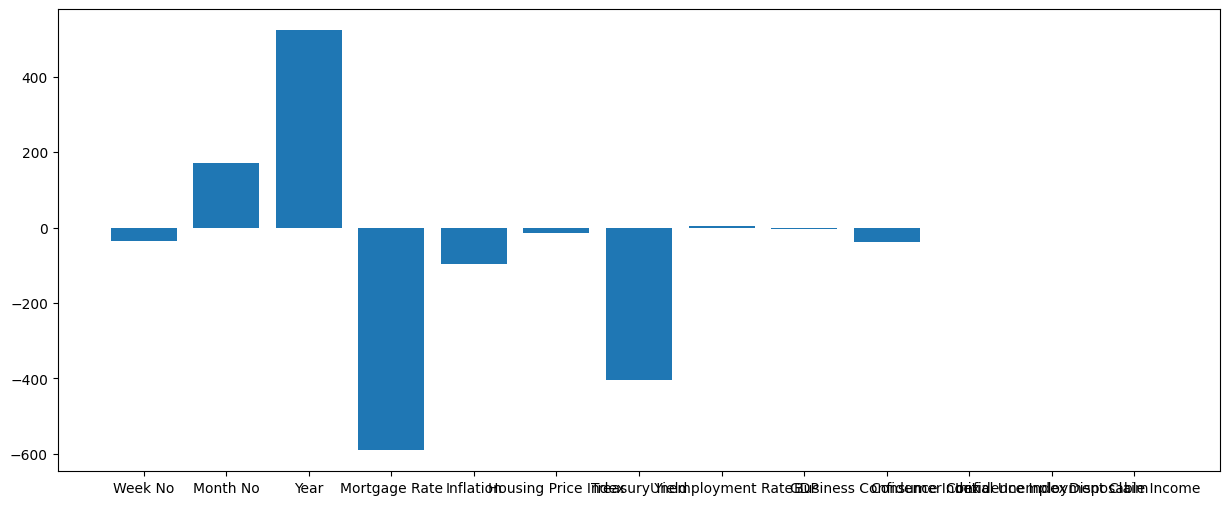

In [58]:
# import Lasso regression from sklearn library
from sklearn.linear_model import Lasso

# Train the model
lassoRegressor = Lasso(alpha = 1) #here setting alpha is nothing but lambda in the formula
lassoRegressor.fit(X_train, y_train)
y_predicted_lasso = lassoRegressor.predict(X_test)

# calculating Mean Squared Error (mse)
R_squared = r2_score(y_predicted_lasso,y_test)
print("R squared Error on test set : ", R_squared)

coefficient_df["Column_Name"] = X_train.columns
coefficient_df['Coefficient_Value_lasso'] = pd.Series(lassoRegressor.coef_)
#print(coefficient_df.head)
#coefficient_df.to_csv('coeff_values.csv',index=False)

plt.rcParams["figure.figsize"] = (15,6)
 
plt.bar(coefficient_df["Column_Name"],coefficient_df["Coefficient_Value_lasso"])

In [61]:
coefficient_df

,Column_Name,Coefficient_Value,Coefficient_Value_ridge,Coefficient_Value_lasso
0,Week No,-39.05,-36.83,-34.90
1,Month No,190.51,177.95,170.40
2,Year,553.30,512.31,523.11
3,Mortgage Rate,-588.89,-587.80,-590.62
4,Inflation,-94.76,-99.19,-96.29
5,Housing Price Index,-16.34,-14.60,-15.08
6,Treasury Yield,-406.58,-406.13,-403.73
7,Unemployment Rate,4.21,4.53,4.77
8,GDP,-5.16,-5.13,-5.10
9,Business Confidence Index,-40.60,-40.26,-37.82


In [62]:
lasso_coeff_zero=[]

In [63]:
index = len(coefficient_df.Coefficient_Value_lasso)

In [64]:
index

13

In [65]:
i=0
while i<index:
    if coefficient_df.Coefficient_Value_lasso[i]==0:
        value=coefficient_df.Column_Name[i]
        lasso_coeff_zero.append(value)
    i=i+1
lasso_coeff_zero

[]

In [66]:
len(lasso_coeff_zero)

0

In [55]:
#Using Pearson Correlation  ranges from -1 to +1  range from -1-- highly negatively correlated to +1-- highly positively correlated


Discount incrs -- sales incres -- highly  postive correlation --- 0.96

Discount incres -- profit decres -- highly negtive correlation   --- -0.97

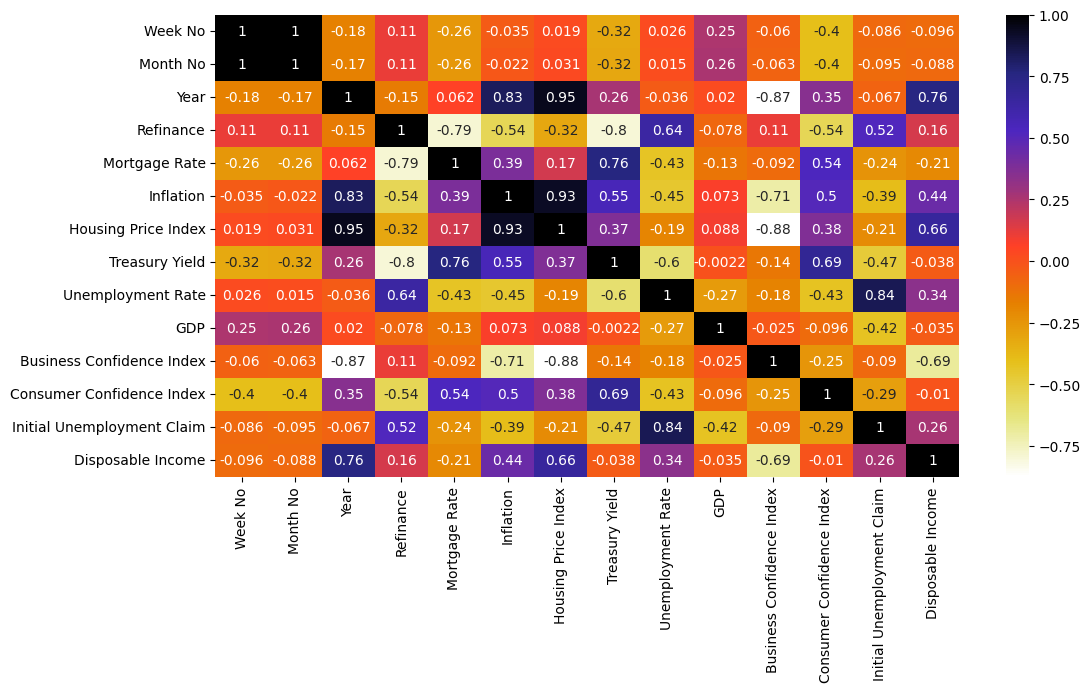

In [69]:
import seaborn as sns
plt.figure(figsize=(12,6))
cor = base_data.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()


#Price discount --- Sales will increase  -- negatively


#Demand incs -- sales incs   -- postive

In [70]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation_check(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        print(i)
        for j in range(i):
            print(j)
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i] # getting the name of column
                print(colname)
                col_corr.add(colname)
    return col_corr

In [71]:
corr_features = correlation_check(X_train, 0.9)
len(set(corr_features))

0
1
0
Month No
2
0
1
3
0
1
2
4
0
1
2
3
5
0
1
2
Housing Price Index
3
4
Housing Price Index
6
0
1
2
3
4
5
7
0
1
2
3
4
5
6
8
0
1
2
3
4
5
6
7
9
0
1
2
3
4
5
6
7
8
10
0
1
2
3
4
5
6
7
8
9
11
0
1
2
3
4
5
6
7
8
9
10
12
0
1
2
3
4
5
6
7
8
9
10
11


2

In [72]:
corr_features

{'Housing Price Index', 'Month No'}

In [73]:
base_data_upd = base_data.drop(['Week No','Year'],axis=1)

In [75]:
base_data.head(2)

,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,1,1,2019,885.00,4.51,1.60,187.90,1.70,4.00,2.40,101.01,101.00,329495.25,16027.80
1,2,1,2019,1094.00,4.51,1.60,187.90,2.16,4.00,2.40,101.01,101.00,348680.14,16027.80


In [76]:
base_data_upd.head(2)

,Month No,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,1,885.00,4.51,1.60,187.90,1.70,4.00,2.40,101.01,101.00,329495.25,16027.80
1,1,1094.00,4.51,1.60,187.90,2.16,4.00,2.40,101.01,101.00,348680.14,16027.80


In [77]:
x=base_data_upd.drop('Refinance',axis=1)
y=base_data_upd['Refinance']

In [80]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.05,random_state=10)

In [81]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(178, 11) (10, 11) (178,) (10,)


In [82]:
validation_table_train_upd = model_validation('train',X_train,X_test,y_train,y_test)

In [83]:
validation_table_train_upd

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,319.73,178913.61,422.98,18.03,0.81
1,<class 'sklearn.linear_model._coordinate_desce...,319.87,178936.95,423.01,18.01,0.81
2,<class 'sklearn.linear_model._ridge.Ridge'>,320.11,179007.76,423.09,17.97,0.81
3,<class 'sklearn.tree._classes.DecisionTreeRegr...,0.00,0.00,0.00,0.00,1.00
4,<class 'sklearn.ensemble._forest.RandomForestR...,98.03,23199.12,152.31,4.97,0.97
5,<class 'sklearn.ensemble._bagging.BaggingRegre...,101.68,26340.13,162.30,4.65,0.97


In [84]:
validation_table_test_upd = model_validation('test',X_train,X_test,y_train,y_test)

In [85]:
validation_table_test_upd

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,490.33,402364.87,634.32,27.47,0.52
1,<class 'sklearn.linear_model._coordinate_desce...,491.17,401700.63,633.80,27.55,0.52
2,<class 'sklearn.linear_model._ridge.Ridge'>,494.88,403908.56,635.54,27.81,0.52
3,<class 'sklearn.tree._classes.DecisionTreeRegr...,483.30,418870.90,647.20,23.25,0.50
4,<class 'sklearn.ensemble._forest.RandomForestR...,405.84,369370.51,607.76,19.41,0.56
5,<class 'sklearn.ensemble._bagging.BaggingRegre...,463.58,456490.10,675.64,22.20,0.45


In [86]:
from sklearn.preprocessing import StandardScaler
def StandardScaler_of_data(x,X_train,X_test):    
    if x=='train':
        print("runningin in training mode")
        le=StandardScaler()
        le.fit(X_train)
        x=le.transform(X_train)
        dat1=pd.DataFrame(x)
        dat1.columns=X_train.columns
        data=dat1
    else:
        print("running in test mode")
        le=StandardScaler()
        le.fit(X_train)
        x=le.transform(X_test)
        dat1=pd.DataFrame(x)        
        dat1.columns=X_test.columns
        data=dat1
    return data

In [87]:
X_train_std = StandardScaler_of_data('train',X_train,X_test)

runningin in training mode


In [88]:
X_train.head(2)

,Month No,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
151,11,2.98,6.80,254.16,1.11,4.20,6.90,97.84,97.55,242973.57,18269.50
35,9,3.58,1.70,195.25,1.14,3.50,2.80,100.90,100.89,174037.71,16319.70


In [89]:
X_train_std.head(2)

,Month No,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,1.46,-0.75,1.12,0.99,-0.91,-0.45,0.36,-0.90,-1.07,-0.42,0.61
1,0.86,0.06,-0.69,-0.99,-0.85,-0.71,0.03,1.00,-0.01,-0.50,-1.14


In [90]:
X_train.shape

(178, 11)

In [91]:
X_test_std = StandardScaler_of_data('test',X_train,X_test)

running in test mode


In [92]:
X_test.shape

(10, 11)

In [93]:
X_test.head(2)

,Month No,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
143,10,2.86,6.20,252.14,1.47,4.60,6.90,98.01,97.87,289370.71,18166.30
10,3,4.41,1.90,190.28,2.16,3.80,2.40,101.29,101.29,205025.71,16107.10


In [94]:
X_test_std.head(2)

,Month No,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,1.16,-0.91,0.90,0.92,-0.18,-0.30,0.36,-0.79,-0.97,-0.37,0.52
1,-0.94,1.18,-0.62,-1.15,1.24,-0.60,0.00,1.24,0.12,-0.46,-1.33


In [95]:
validation_table_train_upd_new = model_validation('train',X_train_std,X_test_std,y_train,y_test)

In [96]:
validation_table_train_upd_new

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,319.73,178913.61,422.98,18.03,0.81
1,<class 'sklearn.linear_model._coordinate_desce...,319.71,179036.76,423.13,18.04,0.81
2,<class 'sklearn.linear_model._ridge.Ridge'>,319.72,179047.10,423.14,18.02,0.81
3,<class 'sklearn.tree._classes.DecisionTreeRegr...,0.00,0.00,0.00,0.00,1.00
4,<class 'sklearn.ensemble._forest.RandomForestR...,98.48,22681.79,150.60,4.95,0.98
5,<class 'sklearn.ensemble._bagging.BaggingRegre...,108.65,31084.39,176.31,5.35,0.97


In [97]:
validation_table_test_upd_new = model_validation('test',X_train_std,X_test_std,y_train,y_test)

In [98]:
validation_table_test_upd_new

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,490.33,402364.87,634.32,27.47,0.52
1,<class 'sklearn.linear_model._coordinate_desce...,488.19,396917.36,630.01,27.53,0.52
2,<class 'sklearn.linear_model._ridge.Ridge'>,487.69,396022.72,629.30,27.51,0.53
3,<class 'sklearn.tree._classes.DecisionTreeRegr...,476.30,409924.90,640.25,23.07,0.51
4,<class 'sklearn.ensemble._forest.RandomForestR...,401.76,358033.69,598.36,19.36,0.57
5,<class 'sklearn.ensemble._bagging.BaggingRegre...,394.81,319097.87,564.89,19.19,0.62


In [ ]:
As of now we have tried correlation to remove the correlated features, and tried satndardisation also -- some how the accuracy got improved -- still we need to improve the accuracy

The next step which we can follow is Hyper parameter tuning for the Algorithms

Grid Search Cv andRrandom Search CV

In [99]:
from sklearn.model_selection import GridSearchCV

ridge=Ridge()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(x,y)

,estimator,Ridge()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


In [100]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 10}
-740666.8959380179


In [101]:
lasso=Lasso()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)

lasso_regressor.fit(x,y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

C:\Users\Admin\.conda\envs\python_311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.394e+07, tolerance: 1.435e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\Admin\.conda\envs\python_311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.241e+07, tolerance: 1.364e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\Admin\.conda\envs\python_311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularis

{'alpha': 50}
-771319.7162817136


In [102]:
model = RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
print("Train Accuracy:",model.score(X_train, y_train))
print("Test Accuracy:",model.score(X_test, y_test))

Train Accuracy: 0.9757095388710892
Test Accuracy: 0.5726096365659794


In [104]:
import pickle

In [105]:
# save the model to disk
filename = 'RF_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [106]:
X_train.head(2)

,Month No,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
151,11,2.98,6.80,254.16,1.11,4.20,6.90,97.84,97.55,242973.57,18269.50
35,9,3.58,1.70,195.25,1.14,3.50,2.80,100.90,100.89,174037.71,16319.70


In [107]:
X_train.columns

Index(['Month No', 'Mortgage Rate', 'Inflation', 'Housing Price Index',
       'Treasury Yield', 'Unemployment Rate', 'GDP',
       'Business Confidence Index', 'Consumer Confidence Index',
       'Initial Unemployment Claim', 'Disposable Income'],
      dtype='object')

In [114]:
future_data.head(2)

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
188,2022-08-08,32,8,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06
189,2022-08-15,33,8,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06


In [109]:
#We need to drop 'Week No' and Year
pred_data = future_data[['Month No', 'Mortgage Rate', 'Treasury Yield',
       'Unemployment Rate', 'GDP', 'Consumer Confidence Index',
       'Disposable Income']]

In [115]:
def predictions_on_future_data(future_data):
    '''
    pred_data = future_data[['Month No', 'Mortgage Rate', 'Treasury Yield',
       'Unemployment Rate', 'GDP', 'Consumer Confidence Index',
       'Disposable Income']]
    '''
    pred_data = future_data.drop(['Date','Week No','Year','Refinance'],axis=1)
    filename = 'RF_model.sav'
    rf_model = pickle.load(open(filename, 'rb'))
    y_pred = rf_model.predict(pred_data)
    print(y_pred)
    future_data['Purchase_Pred'] = y_pred
    
    return future_data

In [116]:
preds = predictions_on_future_data(future_data)

[860.82 860.82 860.82 860.82 860.82 860.82 860.82 860.82 860.82 860.82
 860.82 860.82 860.82]


C:\Users\Admin\AppData\Local\Temp\ipykernel_2292\2324605309.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future_data['Purchase_Pred'] = y_pred


In [117]:
preds

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income,Purchase_Pred
188,2022-08-08,32,8,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
189,2022-08-15,33,8,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
190,2022-08-22,34,8,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
191,2022-08-29,35,8,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
192,2022-09-05,36,9,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
193,2022-09-12,37,9,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
194,2022-09-19,38,9,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
195,2022-09-26,39,9,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
196,2022-10-02,40,10,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82
197,2022-10-09,41,10,2022,NaN,5.41,9.10,274.25,2.38,3.60,2.50,96.60,105.14,213138.56,18423.06,860.82


In [96]:
preds.to_excel("predictions_on_future_data.xlsx",index=False)

In [97]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 50, num = 10)]
# Number of features to consider at every split
max_features = ['auto']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 60, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2,4,6]
# Minimum number of samples required at each leaf node
min_samples_leaf = [2,4,6]
# Method of selecting samples for training each tree
bootstrap = [True, False]
criterion = ['mse','mae']
# Create the parameters grid

param_grid = {'n_estimators': n_estimators,
              'criterion': criterion,
              'max_features': max_features,
              'max_depth': max_depth,
              'min_samples_split': min_samples_split,
              'min_samples_leaf': min_samples_leaf,
              'bootstrap': bootstrap}
print(param_grid)

{'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'criterion': ['mse', 'mae'], 'max_features': ['auto'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'min_samples_split': [2, 4, 6], 'min_samples_leaf': [2, 4, 6], 'bootstrap': [True, False]}


In [98]:
from sklearn.model_selection import GridSearchCV
# Create a based model
rf = RandomForestRegressor()
# Instantiate the grid search model
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, 
                          cv = 3, n_jobs = -1, verbose = 2)

In [99]:
# Fit the grid search to the data
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 4320 candidates, totalling 12960 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['mse', 'mae'],
                         'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
                                       110, None],
                         'max_features': ['auto'],
                         'min_samples_leaf': [2, 4, 6],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             verbose=2)

In [100]:
grid_search.best_params_

{'bootstrap': True,
 'criterion': 'mae',
 'max_depth': 100,
 'max_features': 'auto',
 'min_samples_leaf': 2,
 'min_samples_split': 4,
 'n_estimators': 50}

In [101]:
rf_tuned = RandomForestRegressor(n_estimators=50,criterion='mae',max_features='auto', max_depth=100,min_samples_split=4,min_samples_leaf=4,bootstrap=False,n_jobs=-1)

In [102]:
rf_tuned.fit(X_train, y_train)
print("Train Accuracy:",rf_tuned.score(X_train, y_train))
print("Test Accuracy:",rf_tuned.score(X_test, y_test))

Train Accuracy: 0.9179847779498671
Test Accuracy: 0.8126773606381705


In [103]:
def model_validation_rf(x,X_train,X_test,y_train,y_test):
    validation_table=[]
    models=[RandomForestRegressor]
    for i in models:
        rd=i(n_estimators=10,criterion='mse',max_features='auto', max_depth=40,min_samples_split=6,min_samples_leaf=4,bootstrap=False,n_jobs=-1)
        rd.fit(X_train,y_train)
        if x=="train":
            rd.predict(X_train)
            mae=mean_absolute_error(y_train.values,rd.predict(X_train))
            mse=mean_squared_error(y_train.values,rd.predict(X_train))
            rmse=np.sqrt(mean_squared_error(y_train.values,rd.predict(X_train)))
            mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])
            rsquare=r2_score(y_train.values,rd.predict(X_train))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
        #validation_table=pd.DataFrame(validation_table_train)
        #validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
        else:
            rd.predict(X_test)
            mae=mean_absolute_error(y_test.values,rd.predict(X_test))
            mse=mean_squared_error(y_test.values,rd.predict(X_test))
            rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
            mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
            rsquare=r2_score(y_test.values,rd.predict(X_test))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
            
    validation_table=pd.DataFrame(validation_table)
    validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
    return validation_table

In [104]:
val_table_rf_train = model_validation_rf('train',X_train,X_test,y_train,y_test)

In [105]:
val_table_rf_train

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.ensemble._forest.RandomForestR...,172.75,70999.49,266.46,8.29,0.92


In [106]:
val_table_rf_test = model_validation_rf('test',X_train,X_test,y_train,y_test)

In [107]:
val_table_rf_test

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.ensemble._forest.RandomForestR...,299.84,257279.86,507.23,15.12,0.81


In [108]:
# save the model to disk
filename = 'RF_tuned.sav'
pickle.dump(rf_tuned, open(filename, 'wb'))

In [109]:
def predictions_on_future_data(future_data):
    pred_data = future_data[['Week No', 'Year', 'Mortgage Rate', 'Treasury Yield',
       'Unemployment Rate', 'GDP', 'Consumer Confidence Index',
       'Disposable Income']]
    filename = 'RF_tuned.sav'
    rf_model = pickle.load(open(filename, 'rb'))
    y_pred = rf_model.predict(pred_data)
    print(y_pred)
    future_data['Purchase_Pred'] = y_pred
    
    return future_data

In [110]:
preds_tuned = predictions_on_future_data(future_data)

[688.8 688.8 688.8 688.8 688.8 688.8 688.8 688.8 688.8 688.8 688.8 688.8
 688.8]


C:\Users\gn221m\Anaconda3\lib\site-packages\ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


## Building XGBoost and doing Hyper Parameter Tuning

In [111]:
import xgboost as xgb
from xgboost import XGBRegressor

In [112]:
model = XGBRegressor()
model.fit(X_train,y_train)
print("Train Accuracy:",model.score(X_train, y_train))
print("Test Accuracy:",model.score(X_test, y_test))

Train Accuracy: 0.9999968351027725
Test Accuracy: 0.8408927277358584


In [113]:
def model_validation_xgboost(x,X_train,X_test,y_train,y_test):
    validation_table=[]
    models=[RandomForestRegressor,XGBRegressor]
    for i in models:
        rd=i()
        rd.fit(X_train,y_train)
        if x=="train":
            rd.predict(X_train)
            mae=mean_absolute_error(y_train.values,rd.predict(X_train))
            mse=mean_squared_error(y_train.values,rd.predict(X_train))
            rmse=np.sqrt(mean_squared_error(y_train.values,rd.predict(X_train)))
            mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])
            rsquare=r2_score(y_train.values,rd.predict(X_train))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
        #validation_table=pd.DataFrame(validation_table_train)
        #validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
        else:
            rd.predict(X_test)
            mae=mean_absolute_error(y_test.values,rd.predict(X_test))
            mse=mean_squared_error(y_test.values,rd.predict(X_test))
            rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
            mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
            rsquare=r2_score(y_test.values,rd.predict(X_test))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
            
    validation_table=pd.DataFrame(validation_table)
    validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
    return validation_table

In [114]:
val_table_xgboost_train = model_validation_xgboost('train',X_train,X_test,y_train,y_test)
val_table_xgboost_train

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.ensemble._forest.RandomForestR...,84.23,16649.60,129.03,4.29,0.98
1,<class 'xgboost.sklearn.XGBRegressor'>,1.20,2.74,1.66,0.06,1.00


In [115]:
val_table_xgboost_test = model_validation_xgboost('test',X_train,X_test,y_train,y_test)
val_table_xgboost_test

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.ensemble._forest.RandomForestR...,313.19,251534.88,501.53,20.09,0.82
1,<class 'xgboost.sklearn.XGBRegressor'>,307.85,218976.18,467.95,14.88,0.84


In [116]:
def hyperParameterTuning_xgboost(X_train, y_train):
    
    param_tuning = {
        'learning_rate': [0.01,0.05,0.1],
        'max_depth': [3, 5, 7, 10],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.3,0.5,0.7],
        'colsample_bytree': [0.3,0.5,0.7],
        'n_estimators' : [int(x) for x in np.linspace(start = 10, stop = 90, num = 5)],
        'objective': ['reg:squarederror']
    }
    print(param_tuning)
    xgb_model = XGBRegressor()

    gsearch = GridSearchCV(estimator = xgb_model,
                           param_grid = param_tuning,
                           cv = 5,
                           n_jobs = -1,
                           verbose = 1)

    gsearch.fit(X_train,y_train)

    return gsearch.best_params_

In [118]:
#hyperParameterTuning_xgboost(X_train, y_train)

In [ ]:
xgb_model = XGBRegressor(
        objective = 'reg:squarederror',
        colsample_bytree = 0.7,
        learning_rate = 0.1,
        max_depth = 10,
        min_child_weight = 1,
        n_estimators = 30,
        subsample = 0.7)

In [ ]:
xgb_model.fit(X_train, y_train, early_stopping_rounds=5, eval_set=[(X_test,y_test)], verbose=False)

In [ ]:
print("Train Accuracy:",xgb_model.score(X_train, y_train))
print("Test Accuracy:",xgb_model.score(X_test, y_test))

In [ ]:
def model_validation_xgboost(x,X_train,X_test,y_train,y_test):
    validation_table=[]
    models=[XGBRegressor]
    for i in models:
        rd=i(objective = 'reg:squarederror',
            colsample_bytree = 0.7,
            learning_rate = 0.1,
            max_depth = 10,
            min_child_weight = 1,
            n_estimators = 30,
            subsample = 0.7)               
        rd.fit(X_train,y_train)
        if x=="train":
            rd.predict(X_train)
            mae=mean_absolute_error(y_train.values,rd.predict(X_train))
            mse=mean_squared_error(y_train.values,rd.predict(X_train))
            rmse=np.sqrt(mean_squared_error(y_train.values,rd.predict(X_train)))
            mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])
            rsquare=r2_score(y_train.values,rd.predict(X_train))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
        #validation_table=pd.DataFrame(validation_table_train)
        #validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
        else:
            rd.predict(X_test)
            mae=mean_absolute_error(y_test.values,rd.predict(X_test))
            mse=mean_squared_error(y_test.values,rd.predict(X_test))
            rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
            mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
            rsquare=r2_score(y_test.values,rd.predict(X_test))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
            
    validation_table=pd.DataFrame(validation_table)
    validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
    return validation_table

In [ ]:
val_table_xgboost_train = model_validation_xgboost('train',X_train,X_test,y_train,y_test)
val_table_xgboost_train

In [ ]:
val_table_xgboost_test = model_validation_xgboost('test',X_train,X_test,y_train,y_test)
val_table_xgboost_test

In [ ]:
# save the model to disk
filename = 'RF_tuned2.sav'
pickle.dump(rf_tuned, open(filename, 'wb'))

In [ ]:
def predictions_on_future_data(future_data):
    pred_data = future_data[['Week No', 'Year', 'Mortgage Rate', 'Treasury Yield',
       'Unemployment Rate', 'GDP', 'Consumer Confidence Index',
       'Disposable Income']]
    filename = 'RF_tuned.sav'
    rf_model = pickle.load(open(filename, 'rb'))
    y_pred = rf_model.predict(pred_data)
    print(y_pred)
    future_data['Refinance_Pred'] = y_pred
    
    return future_data

In [ ]:
preds_tuned1 = predictions_on_future_data(future_data)

In [ ]:
# predictions on entire data
preds_tuned = predictions_on_future_data(d1)

In [ ]:
#preds_tuned1.to_excel("xgb_predictions_on_refinance_future_data2.xlsx", index=False)

In [ ]:
#preds_tuned.to_excel("xgb_predictions_on_refinance_entire_data3.xlsx", index=False)

#### Building Neural network model

In [124]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [119]:
X_train.shape

(169, 8)

In [120]:
X_test.shape

(19, 8)

In [121]:
y_train.shape

(169,)

In [122]:
y_test.shape

(19,)

In [126]:
# Define the deep neural network architecture
def create_regression_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1)  # Output layer with single neuron for regression
    ])
    return model

# Create the model
model = create_regression_model()

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=100, validation_split=0.1, verbose=0)

# Evaluate the model on the train data set
y_pred = model.predict(X_train)

# Calculate evaluation metrics
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)

print("MAE train:", mae)
print("MSE train:", mse)
print("RMSE train:", rmse)
print("R-squared train:", r2)

# Evaluate the model on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE test:", mae)
print("MSE test:", mse)
print("RMSE test:", rmse)
print("R-squared test:", r2)

6/6 [==============================] - 0s 0s/step
MAE train: 931.723432732757
MSE train: 1208742.4936771693
RMSE train: 1099.428257630833
R-squared train: -0.3962815408484348
1/1 [==============================] - 0s 16ms/step
MAE test: 1081.6155299136512
MSE test: 1567832.9221307368
RMSE test: 1252.1313517881167
R-squared test: -0.13918152223064917
